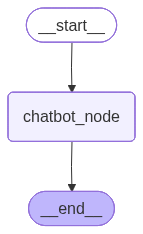

In [18]:
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from typing import TypedDict, Annotated
from dotenv import load_dotenv
load_dotenv()

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0.5,
)

class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    return {"messages": llm.invoke(state["messages"])}

bulider = StateGraph(State)

bulider.add_node("chatbot_node", chatbot)

bulider.add_edge(START, "chatbot_node")
bulider.add_edge("chatbot_node", END)

graph = bulider.compile()
graph


In [19]:
message = [
    {"role": "user", "content": "Who walked on the moon for the first time? Print only the name"}
]
response = graph.invoke({"messages": message})
response

{'messages': [HumanMessage(content='Who walked on the moon for the first time? Print only the name', additional_kwargs={}, response_metadata={}, id='2235d98b-3125-46af-8ca0-e6423389709f'),
  AIMessage(content='Neil Armstrong.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 49, 'total_tokens': 53, 'completion_time': 0.008161054, 'completion_tokens_details': None, 'prompt_time': 0.002363787, 'prompt_tokens_details': None, 'queue_time': 0.045131053, 'total_time': 0.010524841}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c9f85-9702-7d53-bbff-b381c90a0e34-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 4, 'total_tokens': 53})]}

In [21]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    
state = None

while True:
    user_input = input("You: ")

    if user_input.lower() in {"quit", "exit"}:
        break

    if state is None:
        # First message
        state:State = {
            "messages": [
                {"role": "user", "content": user_input}
            ]
        }
    else:
        # Append new user message
        state["messages"].append(
            {"role": "user", "content": user_input}
        )

    # Invoke graph with full state
    state = graph.invoke(state)

    # Print last assistant message
    print("Assistant:", state["messages"][-1].content)
    print(state)

Assistant: Neil Armstrong
{'messages': [HumanMessage(content='Who walked on the moon for the first time? Print only the name', additional_kwargs={}, response_metadata={}, id='d9157377-633e-4c5a-a5a9-ab7495c866a3'), AIMessage(content='Neil Armstrong', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 3, 'prompt_tokens': 49, 'total_tokens': 52, 'completion_time': 0.004668333, 'completion_tokens_details': None, 'prompt_time': 0.002439086, 'prompt_tokens_details': None, 'queue_time': 0.048411951, 'total_time': 0.007107419}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c9f89-0286-7a60-ac2f-c89e922e441e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 3, 'total_tokens': 52})]}
Assistant: July 20, 1969
{'messages': [HumanMessage(content='Who walked on the moon for the first ti

In [24]:
from pprint import pprint
pprint(state)

{'messages': [HumanMessage(content='Who walked on the moon for the first time? Print only the name', additional_kwargs={}, response_metadata={}, id='d9157377-633e-4c5a-a5a9-ab7495c866a3'),
              AIMessage(content='Neil Armstrong', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 3, 'prompt_tokens': 49, 'total_tokens': 52, 'completion_time': 0.004668333, 'completion_tokens_details': None, 'prompt_time': 0.002439086, 'prompt_tokens_details': None, 'queue_time': 0.048411951, 'total_time': 0.007107419}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c9f89-0286-7a60-ac2f-c89e922e441e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 49, 'output_tokens': 3, 'total_tokens': 52}),
              HumanMessage(content='which here', additional_kwargs={}, response_metadata={}, id='0e83f4a3-4369-46